# HLA-B39 Simulation Analysis - Visualization & Analysis

This notebook performs analysis and visualization using preprocessed data.

**Prerequisites:** Run `1_preprocessing_v2.py` first to generate CSV files.

---

In [1]:
import glob
from prody import *
import pandas as pd
import re
import numpy as np
import tqdm
import natsort
import seaborn as sns
import scipy.stats
import matplotlib.pyplot as plt
import py3Dmol
import networkx as nx

## 2.1 Load Preprocessed Data

Load all CSV files generated by the preprocessing script.

In [2]:
# Initialize common variables and load all preprocessed datasets
BASE_FOLDER = '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/'
frame_cols = list(map(str, np.arange(0, 239, 1)))

# Load all CSV files from preprocessing
print('Loading preprocessed datasets...')
df_intEn = pd.read_csv('intEnVdW_2025_07_10.csv')
df_cons_pairs = pd.read_csv('df_cons_pairs_saved_2026_07_27.csv')
df_sig_aff_pairs_b39 = pd.read_csv('df_sig_aff_pairs_b39_2026_07_27.csv')
df_sig_aff_pairs_loaded = pd.read_csv('df_sig_aff_pairs_loaded_2026_07_27.csv')
df_bc_equil = pd.read_csv('df_bc_equil_2025_07_10.csv')
df_bc_equil_cons_resids = pd.read_csv('df_bc_equil_cons_resids_2026_07_27.csv')
df_bc_sig_aff_resids = pd.read_csv('df_bc_sigaff_resids_2026_07_27.csv')

print('All datasets loaded successfully.')
print(f'  - df_intEn: {len(df_intEn)} rows')
print(f'  - df_cons_pairs: {len(df_cons_pairs)} rows')
print(f'  - df_sig_aff_pairs_b39: {len(df_sig_aff_pairs_b39)} rows')
print(f'  - df_sig_aff_pairs_loaded: {len(df_sig_aff_pairs_loaded)} rows')
print(f'  - df_bc_equil_cons_resids: {len(df_bc_equil_cons_resids)} rows')
print(f'  - df_bc_sig_aff_resids: {len(df_bc_sig_aff_resids)} rows')

Loading preprocessed datasets...


/tmp/ipykernel_1562064/1541154879.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_intEn = pd.read_csv('intEnVdW_2025_07_10.csv')


All datasets loaded successfully.
  - df_intEn: 149957 rows
  - df_cons_pairs: 22325 rows
  - df_sig_aff_pairs_b39: 5 rows
  - df_sig_aff_pairs_loaded: 279 rows
  - df_bc_equil_cons_resids: 3910683 rows
  - df_bc_sig_aff_resids: 131 rows


## 2.2 Summary Statistics

Overview of interaction changes by allele and peptide across systems.

In [3]:
# Get unique alleles and peptides from the data
unique_alleles = df_sig_aff_pairs_loaded['allele'].unique()
unique_peptides = df_sig_aff_pairs_loaded['peptide'].unique()

print("=== INTERACTION CHANGES BY ALLELE AND PEPTIDE ===\n")

# Create a mapping of peptides to their full names (you can expand this)
peptide_names = {
    'ALL': 'peptide ALL',
    'A': 'peptide A',  # Update with actual peptide name if known
    'AL': 'peptide AL',  # Update with actual peptide name if known
    # Add more mappings as needed
}

for allele in sorted(unique_alleles):
    print(f"--- {allele} ---")
    allele_data = df_sig_aff_pairs_loaded[df_sig_aff_pairs_loaded['allele'] == allele]
    
    for peptide in sorted(allele_data['peptide'].unique()):
        peptide_data = allele_data[allele_data['peptide'] == peptide]
        
        # Get full peptide name if available
        full_peptide_name = peptide_names.get(peptide, peptide)
        
        repulsive_count = len(peptide_data[peptide_data['change_type'] == 'repulsive'])
        attractive_count = len(peptide_data[peptide_data['change_type'] == 'attractive'])
        
        print(f"  Peptide {peptide} ({full_peptide_name}):")
        print(f"    Repulsive interactions: {repulsive_count}")
        print(f"    Attractive interactions: {attractive_count}")
        print(f"    Total interactions: {repulsive_count + attractive_count}")
    
    print()

# Summary statistics
print("=== OVERALL SUMMARY ===")
total_repulsive = len(df_sig_aff_pairs_loaded[df_sig_aff_pairs_loaded['change_type'] == 'repulsive'])
total_attractive = len(df_sig_aff_pairs_loaded[df_sig_aff_pairs_loaded['change_type'] == 'attractive'])
total_interactions = len(df_sig_aff_pairs_loaded)

print(f"Total significantly affected pairs: {total_interactions}")
print(f"Total repulsive changes: {total_repulsive}")
print(f"Total attractive changes: {total_attractive}")

# Breakdown by allele
print(f"\nBreakdown by allele:")
allele_summary = df_sig_aff_pairs_loaded.groupby(['allele', 'change_type']).size().unstack(fill_value=0)
print(allele_summary)

# Breakdown by peptide
print(f"\nBreakdown by peptide:")
peptide_summary = df_sig_aff_pairs_loaded.groupby(['peptide', 'change_type']).size().unstack(fill_value=0)
print(peptide_summary)

=== INTERACTION CHANGES BY ALLELE AND PEPTIDE ===

--- B3801 ---
  Peptide A (peptide A):
    Repulsive interactions: 1
    Attractive interactions: 89
    Total interactions: 90
  Peptide AL (peptide AL):
    Repulsive interactions: 1
    Attractive interactions: 89
    Total interactions: 90
  Peptide ALL (peptide ALL):
    Repulsive interactions: 1
    Attractive interactions: 89
    Total interactions: 90

--- B3901 ---
  Peptide A (peptide A):
    Repulsive interactions: 1
    Attractive interactions: 0
    Total interactions: 1
  Peptide AL (peptide AL):
    Repulsive interactions: 1
    Attractive interactions: 1
    Total interactions: 2

--- B3906 ---
  Peptide A (peptide A):
    Repulsive interactions: 0
    Attractive interactions: 1
    Total interactions: 1
  Peptide AL (peptide AL):
    Repulsive interactions: 0
    Attractive interactions: 2
    Total interactions: 2
  Peptide ALL (peptide ALL):
    Repulsive interactions: 1
    Attractive interactions: 2
    Total inter

In [4]:
# Explore available data combinations
print("Available alleles:", sorted(df_sig_aff_pairs_loaded['allele'].unique()))
print("Available peptides:", sorted(df_sig_aff_pairs_loaded['peptide'].unique()))
print("\nData combinations (allele, peptide):")
combinations = df_sig_aff_pairs_loaded[['allele', 'peptide']].drop_duplicates().sort_values(['allele', 'peptide'])
for _, row in combinations.iterrows():
    count = len(df_sig_aff_pairs_loaded[(df_sig_aff_pairs_loaded['allele'] == row['allele']) & 
                                       (df_sig_aff_pairs_loaded['peptide'] == row['peptide'])])
    print(f"  {row['allele']} + {row['peptide']}: {count} pairs")

Available alleles: ['B3801', 'B3901', 'B3906']
Available peptides: ['A', 'AL', 'ALL']

Data combinations (allele, peptide):
  B3801 + A: 90 pairs
  B3801 + AL: 90 pairs
  B3801 + ALL: 90 pairs
  B3901 + A: 1 pairs
  B3901 + AL: 2 pairs
  B3906 + A: 1 pairs
  B3906 + AL: 2 pairs
  B3906 + ALL: 3 pairs


## 2.3 3D Structure Visualization

Visualize significantly affected residue pairs in 3D (red = attractive, blue = repulsive).

In [4]:
def vis_pairs(pdb_file, df_tovis, pair_color='red'):
    pdb_str = open(pdb_file, 'r').read()
    # Initialize viewer
    view = py3Dmol.view(width=800, height=600)

    # Add model from the PDB string
    view.addModel(pdb_str, 'pdb')

    # Apply cartoon representation for the entire protein
    view.setStyle({'cartoon': {}})

    for pair in df_tovis['pair'].unique():
        res1 = pair.split('-')[0]
        res2 = pair.split('-')[1]
        # Highlight residues 182-210 in chain A with Van der Waals (VDW) representation
        view.setStyle({'chain':res1[-1], 'resi':res1[:-1]}, {'sphere': {'radius': 1.0, 'color': pair_color}})
        view.setStyle({'chain':res2[-1], 'resi':res2[:-1]}, {'sphere': {'radius': 1.0, 'color': pair_color}})

    # Zoom to the selected residues
    view.zoomTo()

    # Show the viewer
    view.show()

In [5]:
def generate_pymol_script(pdb_file, df_tovis, pair_color='red', output_file=None):
    """
    Generate a PyMOL script to visualize residue pairs.
    
    Parameters:
    - pdb_file: path to PDB structure file
    - df_tovis: DataFrame with 'pair' column containing pairs like "78M-95M"
    - pair_color: color for spheres ('red' or 'blue')
    - output_file: optional path to save the .pml script
    
    Returns:
    - PyMOL script as a string
    """
    lines = []
    
    # Load structure
    lines.append("# PyMOL visualization script")
    lines.append("# Generated from vis_pairs equivalent")
    lines.append("# Includes Goodsell-style matte rendering settings")
    lines.append("")
    lines.append(f"load {pdb_file}, structure")
    lines.append("")
    
    # Ambient occlusion and Goodsell-style matte rendering settings
    lines.append("# ===========================================")
    lines.append("# Publication-quality Goodsell-style settings")
    lines.append("# ===========================================")
    lines.append("")
    lines.append("# Background")
    lines.append("set bg_color, white")
    lines.append("")
    lines.append("# Ambient occlusion for soft shadows")
    lines.append("set ambient_occlusion_mode, 1")
    lines.append("set ambient_occlusion_scale, 25")
    lines.append("set ambient_occlusion_smooth, 10")
    lines.append("")
    lines.append("# Matte/flat shading (no specular highlights)")
    lines.append("set specular, 0")
    lines.append("set spec_reflect, 0")
    lines.append("set shininess, 0")
    lines.append("")
    lines.append("# Lighting for soft, diffuse look")
    lines.append("set ambient, 0.4")
    lines.append("set direct, 0.6")
    lines.append("set reflect, 0.0")
    lines.append("")
    lines.append("# Ray tracing settings (Goodsell-style)")
    lines.append("set ray_trace_mode, 1")
    lines.append("set ray_trace_gain, 0")
    lines.append("set ray_trace_color, black")
    lines.append("set ray_shadow, 1")
    lines.append("")
    lines.append("# High quality rendering")
    lines.append("set antialias, 2")
    lines.append("set ray_trace_fog, 0")
    lines.append("set depth_cue, 0")
    lines.append("")
    
    # Set up visualization
    lines.append("# Set up cartoon representation")
    lines.append("hide all")
    lines.append("show cartoon, structure")
    lines.append("color gray80, structure")
    lines.append("set cartoon_fancy_helices, 1")
    lines.append("set cartoon_smooth_loops, 1")
    lines.append("")
    
    # Build selection for all residues in pairs
    if len(df_tovis) == 0:
        lines.append("# No pairs to visualize")
        lines.append("")
        lines.append("# To render: ray 2400, 2400")
        lines.append("# To save: png output.png, dpi=300")
        script = "\n".join(lines)
        if output_file:
            with open(output_file, 'w') as f:
                f.write(script)
        return script
    
    selection_parts = []
    for pair in df_tovis['pair'].unique():
        res1 = pair.split('-')[0]
        res2 = pair.split('-')[1]
        chain1 = res1[-1]
        resi1 = res1[:-1]
        chain2 = res2[-1]
        resi2 = res2[:-1]
        selection_parts.append(f"(chain {chain1} and resi {resi1})")
        selection_parts.append(f"(chain {chain2} and resi {resi2})")
    
    # Remove duplicates while preserving order
    seen = set()
    unique_selections = []
    for s in selection_parts:
        if s not in seen:
            seen.add(s)
            unique_selections.append(s)
    
    selection_str = " or ".join(unique_selections)
    
    lines.append("# Select and highlight residue pairs")
    lines.append(f"select pair_residues, {selection_str}")
    lines.append("")
    
    # Show spheres and color
    lines.append("# Show spheres and apply color")
    lines.append("show spheres, pair_residues")
    lines.append(f"color {pair_color}, pair_residues")
    lines.append("set sphere_scale, 1.0, pair_residues")
    lines.append("set sphere_mode, 0")
    lines.append("")
    
    # Zoom to highlighted residues
    lines.append("# Zoom to highlighted residues")
    lines.append("zoom pair_residues")
    lines.append("")
    lines.append("# Deselect to clean up view")
    lines.append("deselect")
    lines.append("")
    lines.append("# ===========================================")
    lines.append("# To render publication-quality image:")
    lines.append("# ray 2400, 2400")
    lines.append("# png output.png, dpi=300")
    lines.append("# ===========================================")
    
    script = "\n".join(lines)
    
    if output_file:
        with open(output_file, 'w') as f:
            f.write(script)
        print(f"PyMOL script saved to: {output_file}")
    
    return script

### B3801 Visualizations

In [ ]:
# Load your PDB structure as a string
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'ALL' and change_type == 'attractive'").copy(),
          'red')

In [5]:
df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'ALL' and change_type == 'attractive'")

,allele,peptide,system,pair,change_type,p_value,q_value,delta_mean,ci_low,ci_high,n_ref_rep,n_test_rep
2,B3801,ALL,B3801_ALL,103M-110M,attractive,0.000311,0.003580,-266.476233,-310.762298,-222.190169,4,3
5,B3801,ALL,B3801_ALL,217M-246M,attractive,0.004866,0.016887,-86.473965,-123.050333,-49.897597,4,3
8,B3801,ALL,B3801_ALL,10M-56B,attractive,0.004202,0.015668,-5.248628,-7.400400,-3.096856,4,3
13,B3801,ALL,B3801_ALL,103M-168M,attractive,0.009466,0.026810,-10.886101,-16.707795,-5.064407,4,3
16,B3801,ALL,B3801_ALL,224M-228M,attractive,0.004505,0.016378,-2.105329,-2.987033,-1.223626,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...
268,B3801,ALL,B3801_ALL,192M-201M,attractive,0.000005,0.000525,-194.701815,-203.083622,-186.320009,4,3
271,B3801,ALL,B3801_ALL,97M-116M,attractive,0.011939,0.030535,-98.263125,-155.313582,-41.212667,4,3
274,B3801,ALL,B3801_ALL,191M-199M,attractive,0.018862,0.043194,-3.238281,-5.482870,-0.993692,4,3
275,B3801,ALL,B3801_ALL,124M-143M,attractive,0.012091,0.030786,-2.020039,-3.199814,-0.840264,4,3


In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'ALL' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3801_ALL_attractive_pairs.pml'
)

In [ ]:
# Load your PDB structure as a string
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'ALL' and change_type == 'repulsive'").copy(),
          'blue')

In [6]:
df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'ALL' and change_type == 'repulsive'")

,allele,peptide,system,pair,change_type,p_value,q_value,delta_mean,ci_low,ci_high,n_ref_rep,n_test_rep
191,B3801,ALL,B3801_ALL,203M-217M,repulsive,0.000234,0.003454,9.394591,7.179112,11.61007,4,3


In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'ALL' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3801_ALL_repulsive_pairs.pml'
)

In [ ]:
# Load your PDB structure as a string
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'AL' and change_type == 'attractive'").copy(),
          'red')

In [7]:
df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'AL' and change_type == 'attractive'")

,allele,peptide,system,pair,change_type,p_value,q_value,delta_mean,ci_low,ci_high,n_ref_rep,n_test_rep
1,B3801,AL,B3801_AL,103M-110M,attractive,0.000311,0.003580,-266.442959,-310.728723,-222.157196,4,4
4,B3801,AL,B3801_AL,217M-246M,attractive,0.004873,0.016887,-86.432603,-123.009008,-49.856198,4,4
7,B3801,AL,B3801_AL,10M-56B,attractive,0.004070,0.015377,-5.018900,-7.135747,-2.902053,4,4
10,B3801,AL,B3801_AL,188M-204M,attractive,0.012494,0.031673,-4.563614,-7.504394,-1.622834,4,4
12,B3801,AL,B3801_AL,103M-168M,attractive,0.009378,0.026810,-10.899523,-16.716279,-5.082768,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...
265,B3801,AL,B3801_AL,82M-89M,attractive,0.024118,0.049964,-9.194995,-16.109792,-2.280198,4,4
267,B3801,AL,B3801_AL,192M-201M,attractive,0.000005,0.000525,-194.682588,-203.063343,-186.301833,4,4
270,B3801,AL,B3801_AL,97M-116M,attractive,0.011912,0.030535,-98.289003,-155.325292,-41.252714,4,4
273,B3801,AL,B3801_AL,191M-199M,attractive,0.019636,0.043992,-3.212393,-5.464929,-0.959857,4,4


In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'AL' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3801_AL_attractive_pairs.pml'
)

In [ ]:
# Load your PDB structure as a string
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'AL' and change_type == 'repulsive'").copy(),
          'blue')

In [8]:
df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'AL' and change_type == 'repulsive'")

,allele,peptide,system,pair,change_type,p_value,q_value,delta_mean,ci_low,ci_high,n_ref_rep,n_test_rep
190,B3801,AL,B3801_AL,203M-217M,repulsive,0.015516,0.038163,7.60331,2.51996,12.686661,4,4


In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'AL' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3801_AL_repulsive_pairs.pml'
)

In [ ]:
# Load your PDB structure as a string
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'A' and change_type == 'attractive'").copy(),
          'red')

In [9]:
df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'A' and change_type == 'attractive'")

,allele,peptide,system,pair,change_type,p_value,q_value,delta_mean,ci_low,ci_high,n_ref_rep,n_test_rep
0,B3801,A,B3801_A,103M-110M,attractive,0.000311,0.003580,-266.375919,-310.660108,-222.091731,4,4
3,B3801,A,B3801_A,217M-246M,attractive,0.004879,0.016887,-86.371824,-122.945308,-49.798340,4,4
6,B3801,A,B3801_A,10M-56B,attractive,0.005017,0.017172,-5.077617,-7.248541,-2.906693,4,4
9,B3801,A,B3801_A,188M-204M,attractive,0.021613,0.047808,-4.029222,-7.024675,-1.033768,4,4
11,B3801,A,B3801_A,103M-168M,attractive,0.009706,0.026810,-10.800675,-16.624902,-4.976449,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...
262,B3801,A,B3801_A,147M-152M,attractive,0.010613,0.027509,-53.573888,-83.397019,-23.750757,4,4
266,B3801,A,B3801_A,192M-201M,attractive,0.000005,0.000525,-194.693063,-203.074303,-186.311824,4,4
269,B3801,A,B3801_A,97M-116M,attractive,0.011821,0.030502,-98.534570,-155.563604,-41.505536,4,4
272,B3801,A,B3801_A,191M-199M,attractive,0.019478,0.043806,-3.229748,-5.485356,-0.974140,4,4


In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'A' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3801_A_attractive_pairs.pml'
)

In [ ]:
# Load your PDB structure as a string
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'A' and change_type == 'repulsive'").copy(),
          'blue')

In [10]:
df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'A' and change_type == 'repulsive'")

,allele,peptide,system,pair,change_type,p_value,q_value,delta_mean,ci_low,ci_high,n_ref_rep,n_test_rep
62,B3801,A,B3801_A,159M-164M,repulsive,0.017436,0.041993,11.392318,3.783061,19.001575,4,4


In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3801' and peptide == 'A' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3801_A_repulsive_pairs.pml'
)

### B3901 Visualizations

In [ ]:
# B3901 ALL - Attractive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3901_ALL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'ALL' and change_type == 'attractive'").copy(),
          'red')

In [11]:
df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'ALL' and change_type == 'attractive'")

,allele,peptide,system,pair,change_type,p_value,q_value,delta_mean,ci_low,ci_high,n_ref_rep,n_test_rep


In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'ALL' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3901_ALL_attractive_pairs.pml'
)

In [ ]:
# B3901 ALL - Repulsive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3901_ALL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'ALL' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'ALL' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'ALL' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3901_ALL_repulsive_pairs.pml'
)

In [ ]:
# B3901 AL - Attractive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3901_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'AL' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'AL' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'AL' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3901_AL_attractive_pairs.pml'
)

In [ ]:
# B3901 AL - Repulsive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3901_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'AL' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'AL' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'AL' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3901_AL_repulsive_pairs.pml'
)

In [ ]:
# B3901 A - Attractive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3901_A_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'A' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'A' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'A' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3901_A_attractive_pairs.pml'
)

In [ ]:
# B3901 A - Repulsive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3901_A_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'A' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'A' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3901' and peptide == 'A' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3901_A_repulsive_pairs.pml'
)

### B3906 Visualizations

In [ ]:
# B3906 ALL - Attractive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3906_ALL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'ALL' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'ALL' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'ALL' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3906_ALL_attractive_pairs.pml'
)

In [ ]:
# B3906 ALL - Repulsive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3906_ALL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'ALL' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'ALL' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'ALL' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3906_ALL_repulsive_pairs.pml'
)

In [ ]:
# B3906 AL - Attractive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3906_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'AL' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'AL' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'AL' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3906_AL_attractive_pairs.pml'
)

In [ ]:
# B3906 AL - Repulsive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3906_AL_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'AL' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'AL' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'AL' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3906_AL_repulsive_pairs.pml'
)

In [ ]:
# B3906 A - Attractive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3906_A_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'A' and change_type == 'attractive'").copy(),
          'red')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'A' and change_type == 'attractive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'A' and change_type == 'attractive'").copy(),
    pair_color='red',
    output_file='B3906_A_attractive_pairs.pml'
)

In [ ]:
# B3906 A - Repulsive interactions
vis_pairs('/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3906_A_1/grinn_output_skip10/system_dry.pdb',
          df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'A' and change_type == 'repulsive'").copy(),
          'blue')

In [ ]:
df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'A' and change_type == 'repulsive'")

In [ ]:
generate_pymol_script(
    '/mnt/MORIA/experiments/hla_b39/2022_10_14_bioe_leviathan_backup/T1DM_B39_traj_analysis/gmx_traj_data/B3801_ALL_1/grinn_output_skip10/system_dry.pdb',
    df_sig_aff_pairs_loaded.query("allele == 'B3906' and peptide == 'A' and change_type == 'repulsive'").copy(),
    pair_color='blue',
    output_file='B3906_A_repulsive_pairs.pml'
)

## 2.4 Network Centrality

Analyze the relationship between evolutionary conservation scores and network centrality changes.

In [12]:
def plot_bc_ridgeplot_grid(df_bc_sig_aff, df_bc_equil, n_residues=5):
    """
    Consolidated ridge plot of BC distributions across the 3 alleles.

    Residue selection:
        For each (allele, peptide), take the n_residues with the largest positive
        diff_bc and the n_residues with the largest negative diff_bc. Union all
        of these into a single deduplicated residue list; assign each residue
        to an "increasers" or "decreasers" group based on the sign of its
        mean diff_bc across every subtype where it is significant.

    Coloring (per subtype, NOT per residue):
        Each peptide-bound distribution is colored from the sign of diff_bc
        for that specific (residue, allele, peptide) combination:
            diff_bc > 0  -> red shade   (BC increases upon binding)
            diff_bc < 0  -> blue shade  (BC decreases upon binding)
            diff_bc NaN  -> gray shade  (not significant for this subtype)
        Light -> dark shading still encodes peptide identity (A, AL, ALL).

    Display:
        Residue labels are remapped on the fly: '<n>_M' -> '<n>_HLA',
        '<n>_B' -> '<n>_B2M'. The figure carries a single shared
        x-axis label ("Betweenness Centrality") and y-axis label
        ("Position").

    Parameters
    ----------
    df_bc_sig_aff : pd.DataFrame
        Significant residues with diff_bc_<allele>_<peptide> columns.
    df_bc_equil : pd.DataFrame
        Equilibrium BC values, with 'system', 'Residue_id', 'BC' columns.
    n_residues : int
        Number of top / bottom residues to collect per (allele, peptide).

    Returns
    -------
    matplotlib.figure.Figure
    """
    from scipy import stats
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    alleles = ['B3801', 'B3901', 'B3906'][::-1] # just a cosmetic reverse order to match with rest of manuscript figure ordering
    peptides = ['A', 'AL', 'ALL']

    # ---- Step 1: Collect candidate residues per subtype direction --------
    increase_resids = set()
    decrease_resids = set()
    for allele in alleles:
        for peptide in peptides:
            sort_col = f'diff_bc_{allele}_{peptide}'
            if sort_col not in df_bc_sig_aff.columns:
                continue
            df_sorted = (df_bc_sig_aff
                         .dropna(subset=[sort_col])
                         .sort_values(sort_col, ascending=False))
            increase_resids.update(df_sorted.head(n_residues)['Residue_id'].tolist())
            decrease_resids.update(df_sorted.tail(n_residues)['Residue_id'].tolist())

    # ---- Step 2: Deduplicate. Group each residue by its dominant trend ---
    candidate_resids = sorted(increase_resids | decrease_resids)
    diff_cols = [f'diff_bc_{a}_{p}' for a in alleles for p in peptides
                 if f'diff_bc_{a}_{p}' in df_bc_sig_aff.columns]

    df_cand = (df_bc_sig_aff[df_bc_sig_aff['Residue_id'].isin(candidate_resids)]
               .drop_duplicates(subset='Residue_id', keep='first')
               .copy())
    df_cand['_mean_diff'] = df_cand[diff_cols].mean(axis=1, skipna=True)
    trend = dict(zip(df_cand['Residue_id'], df_cand['_mean_diff']))

    def _chain_pos(rid):
        # 'NN_X' -> (chain, NN). Fallback for malformed ids.
        if '_' in rid:
            num, chain = rid.split('_', 1)
            try:
                return chain, int(num)
            except ValueError:
                return chain, rid
        return rid[-1], rid[:-1]

    # Order residues by chain so HLA sits at the top of the y axis and B2M at
    # the bottom. First entries in all_resids are drawn at the bottom of the y
    # axis (low y_offset), so B2M residues come first in the list and HLA last
    # (top). Within each chain, residues are sorted so positions read in
    # ascending order from top to bottom.
    hla_resids = sorted(
        [r for r in candidate_resids if _chain_pos(r)[0] == 'M'],
        key=lambda r: _chain_pos(r)[1],
        reverse=True,
    )
    b2m_resids = sorted(
        [r for r in candidate_resids if _chain_pos(r)[0] == 'B'],
        key=lambda r: _chain_pos(r)[1],
        reverse=True,
    )
    all_resids = b2m_resids + hla_resids
    print(f"Merged residue set: {len(hla_resids)} HLA (top) + "
          f"{len(b2m_resids)} B2M (bottom) = {len(all_resids)} unique")

    if not all_resids:
        fig, ax = plt.subplots(1, 1)
        ax.text(0.5, 0.5, 'No residues to plot', ha='center', va='center')
        return fig

    # ---- Step 3: Global X-axis range from pooled BC values ---------------
    all_bc_values = []
    for allele in alleles:
        systems = [allele] + [f'{allele}_{pep}' for pep in peptides]
        df_subset = df_bc_equil[
            (df_bc_equil['system'].isin(systems)) &
            (df_bc_equil['Residue_id'].isin(all_resids))
        ]['BC'].dropna()
        all_bc_values.extend(df_subset.tolist())
    if all_bc_values:
        x_min = np.percentile(all_bc_values, 1)
        x_max = np.percentile(all_bc_values, 99)
    else:
        x_min, x_max = 0, 0.1

    # ---- Step 4: Build per-(residue, allele, peptide) diff_bc lookup -----
    df_diff = (df_bc_sig_aff[df_bc_sig_aff['Residue_id'].isin(all_resids)]
               .drop_duplicates(subset='Residue_id', keep='first')
               .set_index('Residue_id'))

    def _diff_sign(resid, allele, pep):
        col = f'diff_bc_{allele}_{pep}'
        if resid not in df_diff.index or col not in df_diff.columns:
            return 0  # treat as not significant
        val = df_diff.at[resid, col]
        if pd.isna(val):
            return 0
        return 1 if val > 0 else -1

    # ---- Step 5: Figure -------------------------------------------------
    fig, axes = plt.subplots(
        1, 3,
        figsize=(10, max(8, len(all_resids) * 0.5)),
        sharey=True,
    )

    # Peptide shade families: light -> dark = A, AL, ALL
    red_shades  = {'A': '#FFCCCC', 'AL': '#FF6666', 'ALL': '#CC0000'}
    red_edges   = {'A': '#FF9999', 'AL': '#FF3333', 'ALL': '#990000'}
    blue_shades = {'A': '#CCE5FF', 'AL': '#6699FF', 'ALL': '#0033CC'}
    blue_edges  = {'A': '#99CCFF', 'AL': '#3366FF', 'ALL': '#002299'}
    gray_shades = {'A': '#E5E5E5', 'AL': '#AAAAAA', 'ALL': '#555555'}
    gray_edges  = {'A': '#BBBBBB', 'AL': '#888888', 'ALL': '#333333'}

    def _relabel(rid):
        """'<n>_M' -> '<n>_HLA', '<n>_B' -> '<n>_B2M', otherwise unchanged."""
        if rid.endswith('_M'):
            return rid[:-2] + '_HLA'
        if rid.endswith('_B'):
            return rid[:-2] + '_B2M'
        return rid

    def _format_allele(a):
        """'B3801' -> 'B*38:01'. Internal column/system names are unchanged."""
        if len(a) == 5 and a[0] == 'B' and a[1:].isdigit():
            return f'B*{a[1:3]}:{a[3:5]}'
        return a

    for col_idx, allele in enumerate(alleles):
        ax = axes[col_idx]

        peptide_free_system = allele
        all_systems = [peptide_free_system] + [f'{allele}_{pep}' for pep in peptides]

        df_plot = df_bc_equil[
            (df_bc_equil['system'].isin(all_systems)) &
            (df_bc_equil['Residue_id'].isin(all_resids))
        ].copy()

        if len(df_plot) == 0:
            ax.text(0.5, 0.5, f'No data for {allele}',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(_format_allele(allele), fontsize=14, fontweight='bold')
            continue

        y_offset = 0
        y_positions = []
        y_labels = []

        for resid in all_resids:
            df_res = df_plot[df_plot['Residue_id'] == resid]
            x_range = np.linspace(x_min, x_max, 150)

            # Stack peptide-bound distributions back-to-front
            # (ALL = darkest, drawn first so lighter A/AL sit in front).
            for pep in reversed(peptides):
                system = f'{allele}_{pep}'
                df_sys = df_res[df_res['system'] == system]['BC'].dropna()
                if len(df_sys) <= 10:
                    continue

                sign = _diff_sign(resid, allele, pep)
                if sign > 0:
                    fill_c, edge_c = red_shades[pep], red_edges[pep]
                elif sign < 0:
                    fill_c, edge_c = blue_shades[pep], blue_edges[pep]
                else:
                    fill_c, edge_c = gray_shades[pep], gray_edges[pep]

                try:
                    kde = stats.gaussian_kde(df_sys)
                    density = kde(x_range)
                    if density.max() > 0:
                        density = density / density.max() * 0.7
                    ax.fill_between(x_range, y_offset, y_offset + density,
                                    alpha=0.6, color=fill_c,
                                    edgecolor=edge_c, linewidth=1.2)
                except Exception:
                    pass

            # Peptide-free on top: dashed reference line, no fill.
            df_pf = df_res[df_res['system'] == peptide_free_system]['BC'].dropna()
            if len(df_pf) > 10:
                try:
                    kde = stats.gaussian_kde(df_pf)
                    density = kde(x_range)
                    if density.max() > 0:
                        density = density / density.max() * 0.7
                    ax.plot(x_range, y_offset + density, color='black',
                            linewidth=2, linestyle='--', alpha=0.9)
                except Exception:
                    pass

            y_positions.append(y_offset + 0.35)
            y_labels.append(_relabel(resid))
            y_offset += 1

        ax.set_yticks(y_positions)
        ax.set_yticklabels(y_labels, fontsize=9)
        # Per-axis xlabel removed; a single fig-level supxlabel is set below.
        ax.set_title(_format_allele(allele), fontsize=14, fontweight='bold')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(-0.5, y_offset + 0.5)

        ax.grid(True, axis='x', linestyle='--', alpha=0.4, color='gray')
        ax.set_axisbelow(True)

        for y in range(1, len(all_resids)):
            ax.axhline(y=y - 0.5, color='lightgray', linewidth=0.5, alpha=0.5)

    # Legend: dashed peptide-free + 3 red shades (increase) + 3 blue shades (decrease)
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Peptide-free'),
        Patch(facecolor=red_shades['A'],   edgecolor=red_edges['A'],   alpha=0.6, label='↑ + Peptide A'),
        Patch(facecolor=red_shades['AL'],  edgecolor=red_edges['AL'],  alpha=0.6, label='↑ + Peptide AL'),
        Patch(facecolor=red_shades['ALL'], edgecolor=red_edges['ALL'], alpha=0.6, label='↑ + Peptide ALL'),
        Patch(facecolor=blue_shades['A'],  edgecolor=blue_edges['A'],  alpha=0.6, label='↓ + Peptide A'),
        Patch(facecolor=blue_shades['AL'], edgecolor=blue_edges['AL'], alpha=0.6, label='↓ + Peptide AL'),
        Patch(facecolor=blue_shades['ALL'],edgecolor=blue_edges['ALL'],alpha=0.6, label='↓ + Peptide ALL'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10,
               bbox_to_anchor=(0.5, 0.005), frameon=True)

    # Single shared axis labels for the whole figure.
    fig.supxlabel('Betweenness Centrality', fontsize=12, y=0.085)
    fig.supylabel('Position', fontsize=12)

    # Reserve the bottom strip of the figure for the shared x-axis label and
    # the legend below it so neither overlaps the plot area.
    fig.tight_layout(rect=[0, 0.11, 1, 1])
    return fig


Merged residue set: 29 HLA (top) + 2 B2M (bottom) = 31 unique


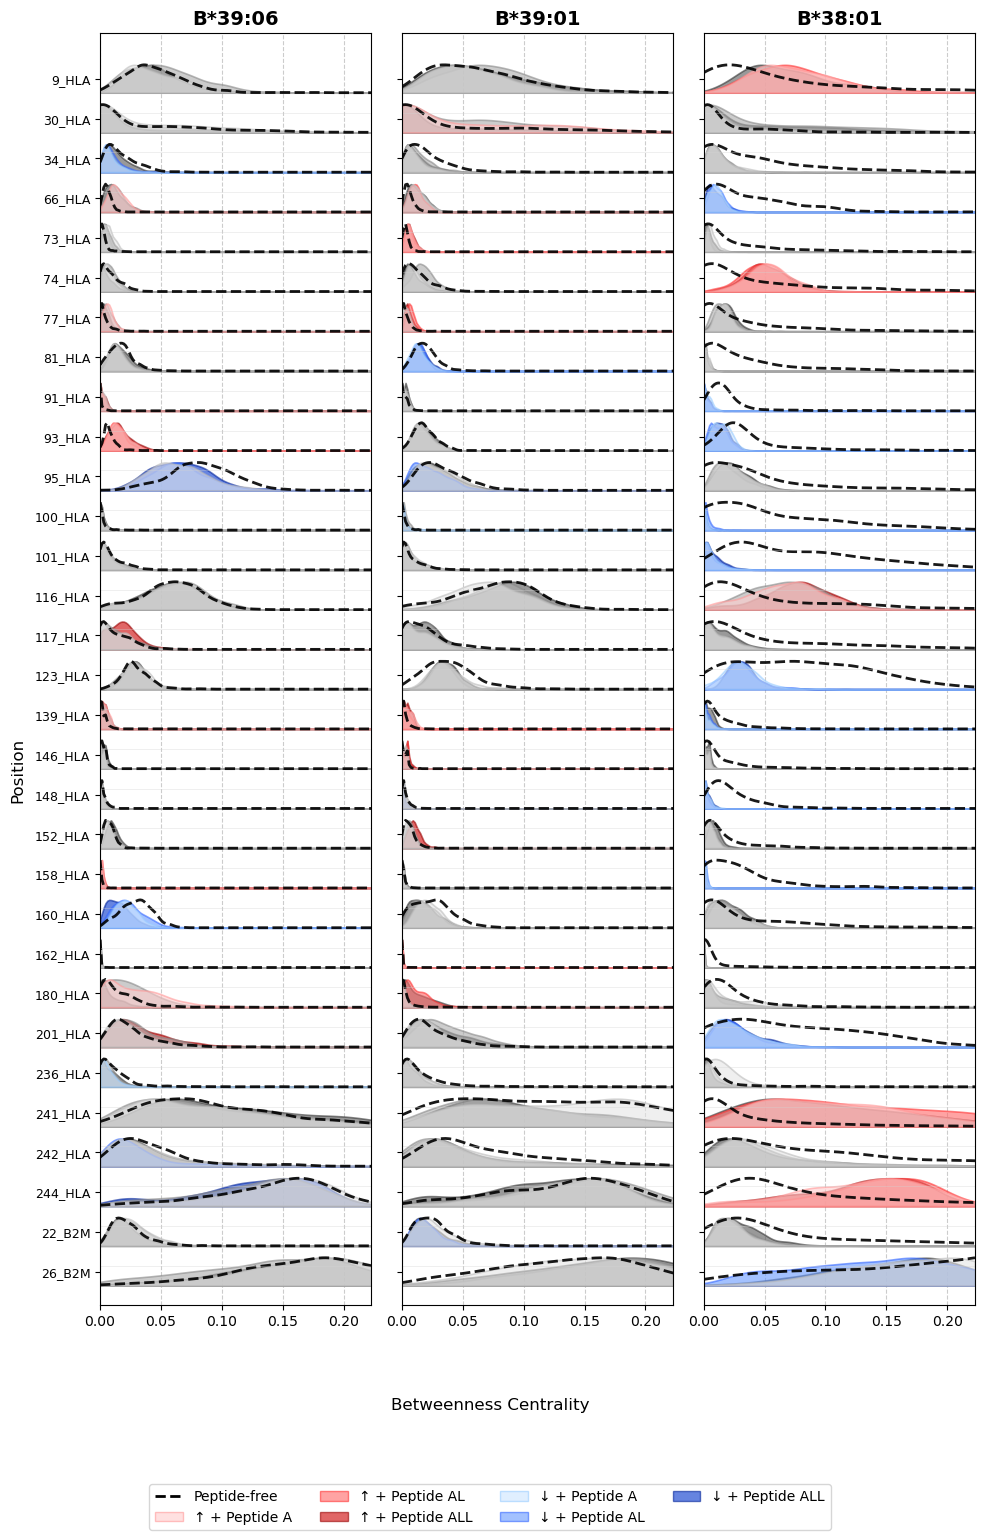

In [13]:
# Generate consolidated ridge plot for all 9 allele-peptide combinations
fig = plot_bc_ridgeplot_grid(
    df_bc_sig_aff_resids,
    df_bc_equil_cons_resids,
    n_residues=3  # 3 top + 3 bottom = 6 per combination
)
plt.show()

# Optionally save to file
fig.savefig('bc_ridgeplot_grid.tiff', dpi=600, bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'})

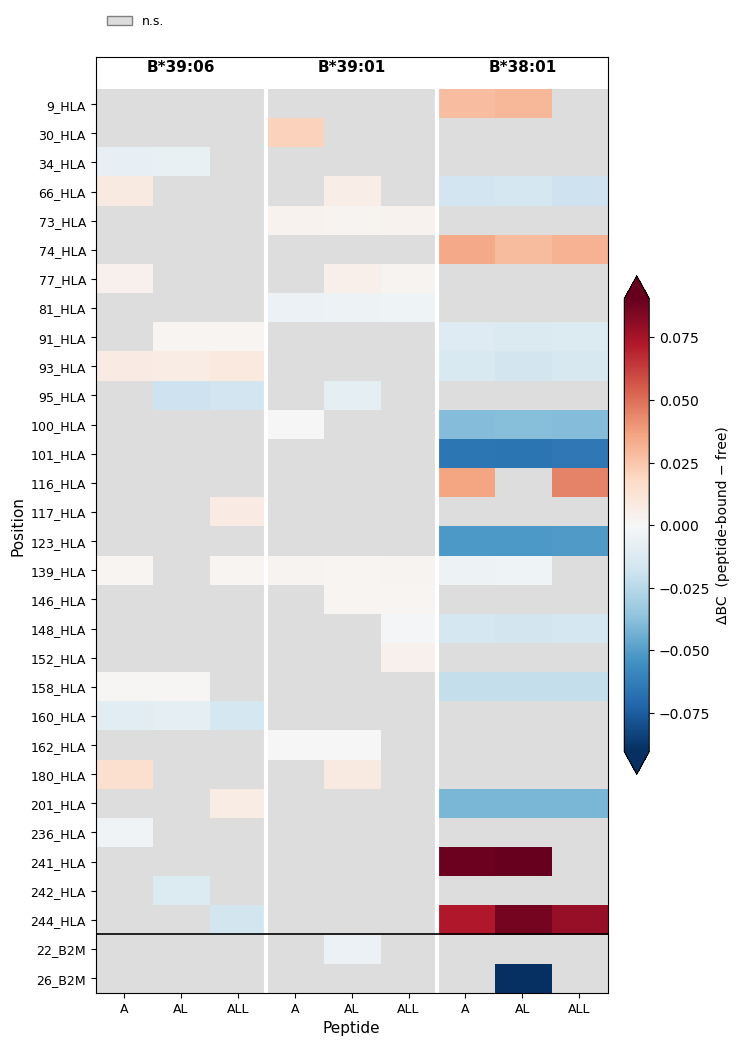

In [14]:
# --- Main-text companion to the ridge plot (Figure 6) ------------------------
# Reviewer feedback: the full ridge plot carries too much information for the
# main text. This compact heatmap shows ONLY the summary ΔBC (median bound -
# median free) of the same key residues, keeping the key message legible.
# The full ridge plots move to the supplementary material.

def plot_bc_delta_heatmap(df_bc_sig_aff, n_residues=3, robust_pct=98):
    """
    Compact 'key message' companion to the full ridge plot (Figure 6).

    Instead of the per-residue BC distributions, this shows only the change in
    betweenness centrality upon peptide binding: ΔBC = median(bound) -
    median(free), for the same key residues the ridge plot highlights.

    Key-residue selection reuses the ridge-plot rule: for each
    (allele, peptide) take the n_residues largest-positive and n_residues
    largest-negative ΔBC residues, then union across all subtypes.

    Layout:
        rows    = key residues (HLA/M chain on top, B2M/B chain at the bottom;
                  ascending position within each chain)
        columns = 9 subtypes, grouped by allele (B*39:06, B*39:01, B*38:01 to
                  match the manuscript ordering), peptides A / AL / ALL within
        color   = diverging red (BC increases on binding) / blue (decreases),
                  centered at 0; non-significant (NaN) cells masked in gray.
    """
    from matplotlib.colors import TwoSlopeNorm
    from matplotlib.patches import Patch

    alleles = ['B3801', 'B3901', 'B3906'][::-1]   # -> B3906, B3901, B3801
    peptides = ['A', 'AL', 'ALL']
    diff_cols = [f'diff_bc_{a}_{p}' for a in alleles for p in peptides
                 if f'diff_bc_{a}_{p}' in df_bc_sig_aff.columns]

    # ---- Key-residue selection (same rule as the ridge plot) -------------
    key = set()
    for c in diff_cols:
        s = df_bc_sig_aff.dropna(subset=[c]).sort_values(c, ascending=False)
        key.update(s.head(n_residues)['Residue_id'].tolist())
        key.update(s.tail(n_residues)['Residue_id'].tolist())

    def _chain_pos(rid):
        if '_' in rid:
            num, chain = rid.split('_', 1)
            try:
                return chain, int(num)
            except ValueError:
                return chain, rid
        return rid[-1], rid[:-1]

    # HLA (M) on top, B2M (B) at the bottom; ascending position within a chain.
    hla = sorted([r for r in key if _chain_pos(r)[0] == 'M'], key=lambda r: _chain_pos(r)[1])
    b2m = sorted([r for r in key if _chain_pos(r)[0] == 'B'], key=lambda r: _chain_pos(r)[1])
    row_resids = hla + b2m   # row 0 = top

    def _relabel(rid):
        if rid.endswith('_M'):
            return rid[:-2] + '_HLA'
        if rid.endswith('_B'):
            return rid[:-2] + '_B2M'
        return rid

    def _format_allele(a):
        if len(a) == 5 and a[0] == 'B' and a[1:].isdigit():
            return f'B*{a[1:3]}:{a[3:5]}'
        return a

    # ---- Build the ΔBC matrix (rows = residues, cols = subtypes) ---------
    df_idx = (df_bc_sig_aff.drop_duplicates(subset='Residue_id', keep='first')
              .set_index('Residue_id'))
    M = np.full((len(row_resids), len(diff_cols)), np.nan)
    for i, rid in enumerate(row_resids):
        for j, c in enumerate(diff_cols):
            if rid in df_idx.index and c in df_idx.columns:
                M[i, j] = df_idx.at[rid, c]
    Mmask = np.ma.masked_invalid(M)

    # Symmetric, robust diverging scale so a few outliers don't wash it out.
    vmax = np.nanpercentile(np.abs(M), robust_pct)
    vmax = vmax if vmax > 0 else np.nanmax(np.abs(M))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad('#DDDDDD')   # non-significant cells

    fig, ax = plt.subplots(figsize=(7.5, max(5, len(row_resids) * 0.34)))
    im = ax.imshow(Mmask, aspect='auto', cmap=cmap, norm=norm)

    # ---- Ticks / labels --------------------------------------------------
    ax.set_xticks(range(len(diff_cols)))
    ax.set_xticklabels(peptides * len(alleles), fontsize=9)
    ax.set_yticks(range(len(row_resids)))
    ax.set_yticklabels([_relabel(r) for r in row_resids], fontsize=9)

    # Allele group headers + vertical separators between alleles.
    npep = len(peptides)
    for k, a in enumerate(alleles):
        ax.text(k * npep + (npep - 1) / 2, -1.0, _format_allele(a),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
        if k > 0:
            ax.axvline(k * npep - 0.5, color='white', linewidth=3)
    # HLA / B2M chain divider.
    if hla and b2m:
        ax.axhline(len(hla) - 0.5, color='black', linewidth=1.2)

    ax.set_xlabel('Peptide', fontsize=11)
    ax.set_ylabel('Position', fontsize=11)
    ax.set_ylim(len(row_resids) - 0.5, -1.6)   # headroom for allele headers

    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03, extend='both')
    cbar.set_label('ΔBC  (peptide-bound − free)', fontsize=10)

    # Only advertise the n.s. color if any key cell is actually masked.
    if Mmask.mask.any():
        ax.legend(handles=[Patch(facecolor='#DDDDDD', edgecolor='gray', label='n.s.')],
                  loc='lower left', bbox_to_anchor=(0, 1.02), fontsize=9, frameon=False)

    fig.tight_layout()
    return fig


# Revised main-text figure: ΔBC of the key residues only.
fig_hm = plot_bc_delta_heatmap(df_bc_sig_aff_resids, n_residues=3)
plt.show()

fig_hm.savefig('bc_delta_heatmap.tiff', dpi=600, bbox_inches='tight',
               pil_kwargs={'compression': 'tiff_lzw'})


### Identify top residues with increased/decreased centrality upon peptide binding

<Axes: xlabel='Residue_id', ylabel='BC'>

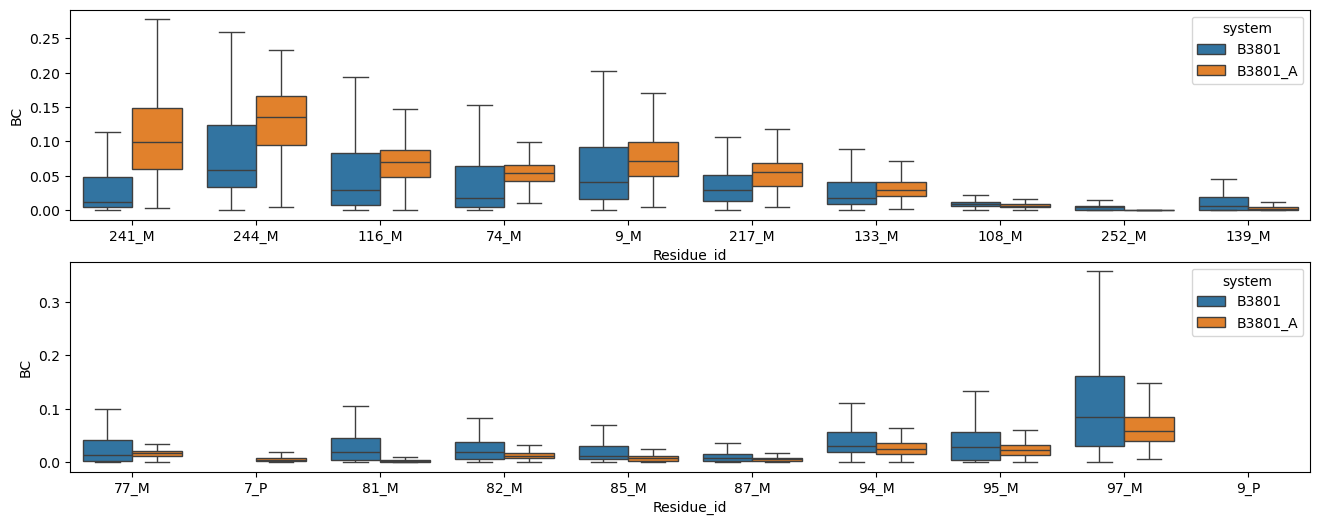

In [15]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3801_A',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3801_A','B3801'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

In [ ]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3801_AL',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3801_AL','B3801'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

In [ ]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3801_ALL',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3801_ALL','B3801'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

In [ ]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3901_A',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3901_A','B3901'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

In [ ]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3901_AL',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3901_AL','B3901'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

In [ ]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3901_ALL',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3901_ALL','B3901'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

In [ ]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3906_A',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3906_A','B3906'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

In [ ]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3906_AL',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3906_AL','B3906'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

In [ ]:
df_bc_sig_aff_resids.sort_values(by='diff_bc_B3906_ALL',ascending=False, inplace=True)
top10_bc = df_bc_sig_aff_resids[:10]
bottom10_bc = df_bc_sig_aff_resids[-10:]
(fig,ax) = plt.subplots(nrows=2,ncols=1,figsize=(16,6))
df_2plot1 = df_bc_equil_cons_resids[df_bc_equil_cons_resids['system'].isin(['B3906_ALL','B3906'])]
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(top10_bc['Residue_id'].values)]
order = top10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[0], order=order,showfliers=False)
df_2plot = df_2plot1[df_2plot1['Residue_id'].isin(bottom10_bc['Residue_id'].values)]
order = bottom10_bc['Residue_id'].values
sns.boxplot(df_2plot,x='Residue_id',y='BC',hue='system', ax= ax[1], order=order,showfliers=False)

## 2.5 Polymorphic Position Analysis

Analyze interaction energies around polymorphic positions.

In [ ]:
def analyze_polymorphic_residue_interactions(df, residue_id, title_suffix="", figsize_per_subplot=(8, 5)):
    # Determine available frame columns dynamically
    potential_frame_cols = [str(i) for i in range(1000)]
    available_frame_cols = [col for col in potential_frame_cols if col in df.columns]
    
    # Get interactions involving the specified residue
    df_residue = df.query(f"resnum_chain1 == '{residue_id}' or resnum_chain2 == '{residue_id}'")
    
    if len(df_residue) == 0:
        print(f"Warning: No interactions found involving residue {residue_id}")
        return {'filtered_df': df_residue, 'unique_pairs': [], 'pair_counts': {}, 'peptide_summary': {}}
    
    print(f"Found {len(df_residue)} interactions involving residue {residue_id}")
    
    # Get unique peptide values and include peptide-free cases
    unique_peptides = df_residue['peptide'].dropna().unique()
    has_peptide_free = df_residue['peptide'].isna().any()
    
    # Create list of conditions to plot
    conditions = []
    if has_peptide_free:
        conditions.append(('Peptide-free', None))
    for peptide in sorted(unique_peptides):
        conditions.append((f'Peptide: {peptide}', peptide))
    
    print(f"Analyzing {len(conditions)} conditions: {len(unique_peptides)} peptide types + {'peptide-free' if has_peptide_free else 'no peptide-free cases'}")
    
    # Get unique interaction pairs
    unique_pairs = df_residue['resnum_chain12'].unique()
    
    # Initialize summary structures
    pair_counts = {}
    peptide_summary = {}
    
    # Create subplots for each interaction pair
    for resnum_chain12 in unique_pairs:
        df_pair = df_residue[df_residue['resnum_chain12'] == resnum_chain12]
        
        if len(df_pair) == 0:
            continue
        
        # Calculate subplot layout
        n_conditions = len(conditions)
        n_cols = 2
        n_rows = 2
        
        # Create figure with subplots
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize_per_subplot[0] * n_cols, figsize_per_subplot[1] * n_rows))
        if n_conditions == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = axes if isinstance(axes, (list, np.ndarray)) else [axes]
        else:
            axes = axes.flatten()
        
        # Plot each condition
        for idx, (condition_name, peptide_value) in enumerate(conditions):
            ax = axes[idx]
            
            # Filter data for this condition
            if peptide_value is None:  # Peptide-free
                df_condition = df_pair[df_pair['peptide'].isna()]
                condition_key = 'peptide_free'
            else:  # Specific peptide
                df_condition = df_pair[df_pair['peptide'] == peptide_value]
                condition_key = peptide_value
            
            if len(df_condition) == 0:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{condition_name}\n(No data)')
                continue
            
            # Initialize condition in summaries if not exists
            if condition_key not in peptide_summary:
                peptide_summary[condition_key] = {}
            
            alleles_plotted = []
            
            # Plot KDE for each allele in this condition
            for allele in df_condition['allele'].unique():
                df_allele = df_condition[df_condition['allele'] == allele]
                
                if len(df_allele) == 0:
                    continue
                    
                interaction_energies = df_allele[available_frame_cols].values.flatten()
                interaction_energies = interaction_energies[~np.isnan(interaction_energies)]
                
                if len(interaction_energies) == 0:
                    continue
                    
                sns.kdeplot(interaction_energies, label=allele, fill=True, alpha=0.7, ax=ax)
                alleles_plotted.append(allele)
                
                # Count pairs per allele and condition
                pair_key = f"{condition_key}_{allele}"
                if pair_key not in pair_counts:
                    pair_counts[pair_key] = 0
                pair_counts[pair_key] += 1
                
                # Update peptide summary
                if allele not in peptide_summary[condition_key]:
                    peptide_summary[condition_key][allele] = 0
                peptide_summary[condition_key][allele] += 1
            
            # Customize subplot
            if alleles_plotted:
                ax.set_title(f'{condition_name}\n{resnum_chain12}')
                ax.set_xlabel('Interaction Energy (kJ/mol)')
                ax.set_ylabel('Density')
                ax.legend(fontsize='small')
                ax.grid(True, alpha=0.3)
            else:
                ax.text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{condition_name}\n(No valid data)')
        
        # Hide unused subplots
        for idx in range(len(conditions), len(axes)):
            axes[idx].set_visible(False)
        
        # Add overall title and adjust layout
        fig.suptitle(f'Interaction energies for {resnum_chain12} across all conditions{title_suffix}', 
                     fontsize=14, y=0.98)
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.show()
    
    # Print comprehensive summary
    print(f"\n=== Summary for residue {residue_id} ===")
    print(f"Total unique interaction pairs: {len(unique_pairs)}")
    print(f"Conditions analyzed: {len(conditions)}")
    
    print(f"\nPairs per condition and allele:")
    for condition_key, allele_counts in peptide_summary.items():
        condition_name = "Peptide-free" if condition_key == 'peptide_free' else f"Peptide: {condition_key}"
        print(f"  {condition_name}: {allele_counts}")
    
    return {
        'filtered_df': df_residue, 
        'unique_pairs': list(unique_pairs), 
        'pair_counts': pair_counts,
        'peptide_summary': peptide_summary,
        'conditions': conditions
    }

In [ ]:
# Analyze residue 74M in peptide-loaded systems
results_74M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '74M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 77M in peptide-loaded systems
results_77M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '77M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 80M in peptide-loaded systems
results_80M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '80M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 81M in peptide-loaded systems
results_81M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '81M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 82M in peptide-loaded systems
results_82M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '82M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 83M in peptide-loaded systems
results_83M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '83M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 95M in peptide-loaded systems
results_95M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '95M', 
    title_suffix=" (Polymorphic Position)"
)

In [ ]:
# Analyze residue 97M in peptide-loaded systems
results_97M = analyze_polymorphic_residue_interactions(
    df_cons_pairs, 
    '97M', 
    title_suffix=" (Polymorphic Position)"
)